In [147]:
def fetch_image_data():
    # TODO
    return

In [148]:
from pathlib import Path
import os

IMAGES_PATH = Path("../../../resources/cloud-images/CCSN_v2")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }

    return labeled_images, cloud_labels

In [115]:
labeled_images, cloud_labels = index_labeled_images()

In [116]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def extract_labels(labeled_images):
    images = []
    labels = []
    for (i, image_name) in enumerate(labeled_images):
        path = labeled_images[image_name]['path']
        image = cv2.imread(path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, (64, 64))
        images.append(image)

        label = labeled_images[image_name]['label']
        labels.append(label)

    return np.array(images), np.array(labels)

In [149]:
images, labels = extract_labels(labeled_images)

In [150]:
def split_train_test():
    # TODO with this and the below code blocks
    return

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

ordinal_encoder = LabelEncoder()
labels_encoded = ordinal_encoder.fit_transform(labels)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels_encoded))

X_train, X_test = images[train_idx], images[test_idx]
y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)


train: (2034, 64, 64) (2034,)
test:  (509, 64, 64) (509,)


In [151]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

In [152]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [153]:
from sklearn.metrics import precision_score, recall_score, f1_score

def display_clf_scores(labels, predictions):
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)


In [154]:
from typing import Dict, Any
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


def get_default_classifiers(random_state: int = 42) -> Dict[str, Any]:
    """
    Return a dictionary of main classification models (some with scaling).
    """
    return {
        "gaussian_nb": GaussianNB(),
        "log_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=random_state))
        ]),
        "linear_svc": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SGDClassifier(loss="hinge", random_state=random_state))
        ]),
        "svc_rbf": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=random_state))
        ]),
        "knn": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "decision_tree": DecisionTreeClassifier(random_state=random_state),
        "random_forest": RandomForestClassifier(random_state=random_state),
        "gradient_boosting": GradientBoostingClassifier(random_state=random_state,
                                                        n_estimators=150,
                                                        learning_rate=0.1,
                                                        max_depth=3,
                                                        subsample=0.7
                                                        ),
        "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=random_state),
        "mlp": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(max_iter=500, random_state=random_state))
        ])
    }


def evaluate_classifiers(X, y, scoring: str = "accuracy", cv: int = 5,
                         n_jobs: int = -1, random_state: int = 42,
                         verbose: int = 1
) -> pd.DataFrame:
    """
    Evaluate many classification models with default hyperparameters.
    Returns a sorted dataframe of cross-validation results.
    """
    classifiers = get_default_classifiers(random_state)
    cv_obj = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    results = []

    for name, clf in classifiers.items():
        if verbose:
            print(f"\nEvaluating model: {name}")

        t0 = time.perf_counter()

        scores = cross_val_score(
            clf, X, y,
            scoring=scoring,
            cv=cv_obj,
            n_jobs=n_jobs
        )

        t1 = time.perf_counter()

        results.append({
            "model": name,
            "mean_score": np.mean(scores),
            "std_score": np.std(scores),
            "time_elapsed": t1 - t0
        })

    return pd.DataFrame(results).sort_values("mean_score", ascending=False)


In [ ]:
# can skip the below as we've concluded that we'll explore 1) random forest 2) mlp 3)svc

# results = evaluate_classifiers(X_train_flat, y_train, scoring="f1_macro", cv=5)
# print(results)


Evaluating model: gaussian_nb

Evaluating model: log_reg

Evaluating model: linear_svc

Evaluating model: svc_rbf

Evaluating model: knn

Evaluating model: decision_tree

Evaluating model: random_forest

Evaluating model: gradient_boosting

Evaluating model: hist_gradient_boosting

Evaluating model: mlp
                    model  mean_score  std_score  time_elapsed
7       gradient_boosting    0.249540   0.010886    917.842738
8  hist_gradient_boosting    0.248760   0.005808    123.033588
6           random_forest    0.242161   0.015370      3.676388
9                     mlp    0.211470   0.026213      4.508299
3                 svc_rbf    0.196986   0.013427     12.453825
2              linear_svc    0.190364   0.011519      5.036427
4                     knn    0.187575   0.012554      1.006303
5           decision_tree    0.178849   0.012698      4.152716
0             gaussian_nb    0.165809   0.005751      1.258407
1                 log_reg    0.165537   0.011160      5.153570


In [32]:
# Researching Random Forest Time estimate = ~ 400 seconds = ~ 7 minutes

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

param_grid = {
    "n_estimators": [200, 350, 500],          # 3 levels: low / medium / higher
    "max_features": ["sqrt", "log2"],         # classic vs more random
    "max_depth": [10, 20, None],              # shallow/medium/deep
    "min_samples_leaf": [1, 2],               # low vs slightly regularized
    "bootstrap": [True, False],               # meaningful difference
    "class_weight": ["balanced"],             # fixed for small datasets
}

rf = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [33]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=3,
)


grid_search.fit(X_train_flat, y_train)

grid_search.best_params_, grid_search.best_score_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 2/5] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, n_estimators=200;, score=0.248 total time=   7.4s
[CV 5/5] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, n_estimators=200;, score=0.218 total time=   7.4s
[CV 4/5] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, n_estimators=200;, score=0.243 total time=   7.5s
[CV 3/5] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, n_estimators=200;, score=0.226 total time=   7.5s
[CV 1/5] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, n_estimators=200;, score=0.266 total time=   7.6s
[CV 4/5] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, n_estimators=350;, score=0.259 total time=  13.0s
[CV 1/5]

({'bootstrap': False,
  'class_weight': 'balanced',
  'max_depth': 20,
  'max_features': 'log2',
  'min_samples_leaf': 2,
  'n_estimators': 350},
 np.float64(0.25598076179872853))

In [155]:
import pandas as pd

results = grid_search.cv_results_
results_df = pd.DataFrame(grid_search.cv_results_)

param_cols = [c for c in results_df.columns if c.startswith("param_")]

visible_df = results_df[["rank_test_score", "mean_test_score"] + param_cols]
visible_df.sort_values("rank_test_score").head(20)

,rank_test_score,mean_test_score,param_bootstrap,param_class_weight,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators
58,1,0.255981,False,balanced,20,log2,2,350
65,2,0.254518,False,balanced,None,sqrt,2,500
57,3,0.254118,False,balanced,20,log2,2,200
53,4,0.254107,False,balanced,20,sqrt,2,500
33,5,0.254068,True,balanced,None,log2,2,200
71,6,0.253296,False,balanced,None,log2,2,500
69,7,0.253255,False,balanced,None,log2,2,200
27,8,0.253026,True,balanced,None,sqrt,2,200
59,9,0.252716,False,balanced,20,log2,2,500
52,10,0.252194,False,balanced,20,sqrt,2,350


In [156]:
from scipy.stats import randint, uniform
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": randint(200, 1000),
    "max_depth": randint(15, 25),
    "min_samples_leaf": randint(2, 5),
    "min_samples_split": randint(2, 30),
    "max_features": ["sqrt", "log2"],
    "bootstrap": [False],
    "class_weight": ["balanced"],
}

In [158]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42,
)

random_search.fit(X_train_flat, y_train)

random_search.best_params_, random_search.best_score_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 5/5] END bootstrap=False, class_weight=balanced, max_depth=21, max_features=log2, min_samples_leaf=2, min_samples_split=16, n_estimators=306;, score=0.220 total time=   3.7s
[CV 2/5] END bootstrap=False, class_weight=balanced, max_depth=21, max_features=log2, min_samples_leaf=2, min_samples_split=16, n_estimators=306;, score=0.264 total time=   3.7s
[CV 3/5] END bootstrap=False, class_weight=balanced, max_depth=21, max_features=log2, min_samples_leaf=2, min_samples_split=16, n_estimators=306;, score=0.219 total time=   3.6s
[CV 4/5] END bootstrap=False, class_weight=balanced, max_depth=21, max_features=log2, min_samples_leaf=2, min_samples_split=16, n_estimators=306;, score=0.263 total time=   3.8s
[CV 1/5] END bootstrap=False, class_weight=balanced, max_depth=21, max_features=log2, min_samples_leaf=2, min_samples_split=16, n_estimators=306;, score=0.247 total time=   3.9s
[CV 2/5] END bootstrap=False, class_weight=bala

({'bootstrap': False,
  'class_weight': 'balanced',
  'max_depth': 21,
  'max_features': 'sqrt',
  'min_samples_leaf': 3,
  'min_samples_split': 2,
  'n_estimators': 247},
 np.float64(0.2551676615920409))

In [159]:
import pandas as pd

results = random_search.cv_results_
results_df = pd.DataFrame(random_search.cv_results_)

param_cols = [c for c in results_df.columns if c.startswith("param_")]

visible_df = results_df[["rank_test_score", "mean_test_score"] + param_cols]
visible_df.sort_values("rank_test_score").head(20)

,rank_test_score,mean_test_score,param_bootstrap,param_class_weight,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators
25,1,0.255168,False,balanced,21,sqrt,3,2,247
59,2,0.254793,False,balanced,15,log2,2,17,453
92,3,0.253601,False,balanced,20,sqrt,3,12,643
64,4,0.253137,False,balanced,20,log2,3,4,311
8,5,0.252068,False,balanced,21,log2,2,4,684
4,6,0.251873,False,balanced,16,log2,3,7,585
28,7,0.251663,False,balanced,19,sqrt,3,4,968
1,8,0.251116,False,balanced,22,sqrt,2,8,321
37,9,0.251106,False,balanced,24,sqrt,2,8,389
40,10,0.250882,False,balanced,20,log2,4,10,517


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict


rf_clf = random_search.best_estimator_ #this is the model, fully trained on the training set

In [161]:
cross_val_score(rf_clf, X_train_flat, y_train, cv=3, scoring="f1_macro")

array([0.22890253, 0.22539575, 0.26556487])

In [162]:
y_train_pred = cross_val_predict(rf_clf, X_train_flat, y_train, cv=3)


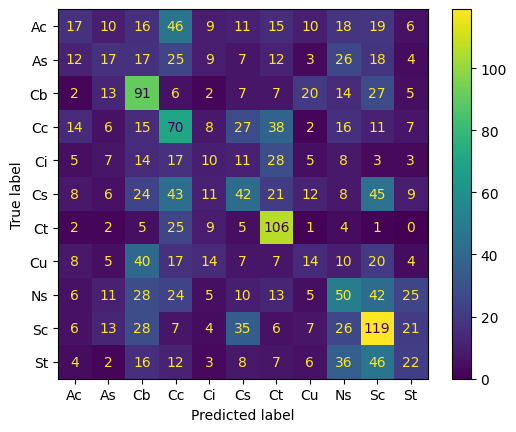

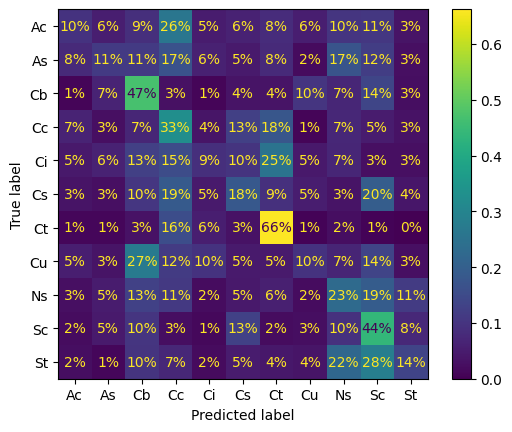

In [164]:
y_train_labels = ordinal_encoder.inverse_transform(y_train)
y_train_pred_labels = ordinal_encoder.inverse_transform(y_train_pred)

conf_mx = ConfusionMatrixDisplay.from_predictions(y_train_labels, y_train_pred_labels)
conf_mx_norm = ConfusionMatrixDisplay.from_predictions(y_train_labels, y_train_pred_labels, normalize="true", values_format=".0%", labels=ordinal_encoder.classes_)
plt.show()

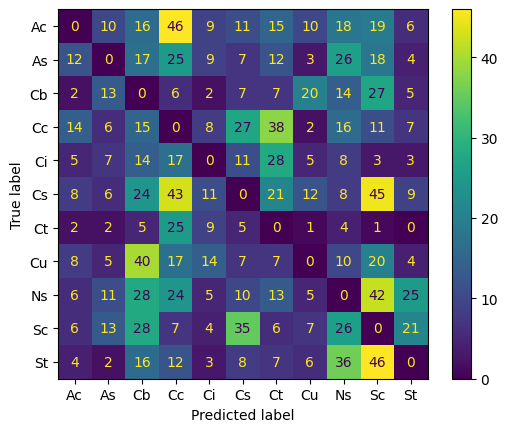

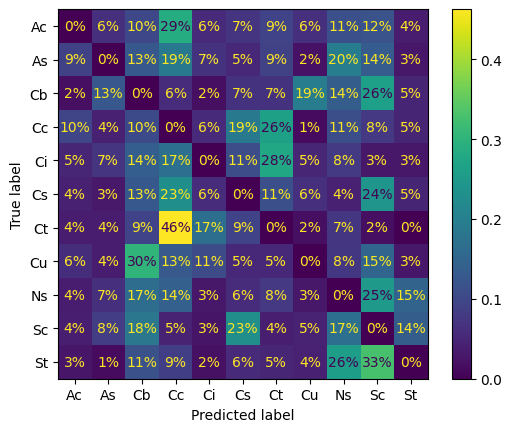

In [168]:
# zeroing the diagonal in the Confusion Matrix

sample_weight = (y_train_pred_labels != y_train_labels)

zeroed_conf_mx = ConfusionMatrixDisplay.from_predictions(y_train_labels, y_train_pred_labels, sample_weight=sample_weight, labels=ordinal_encoder.classes_)
zeroed_conf_mx_norm = ConfusionMatrixDisplay.from_predictions(y_train_labels, y_train_pred_labels, normalize="true", values_format=".0%", labels=ordinal_encoder.classes_, sample_weight=sample_weight)
plt.show()


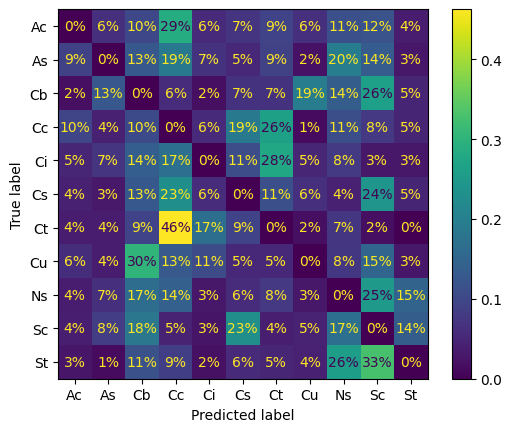

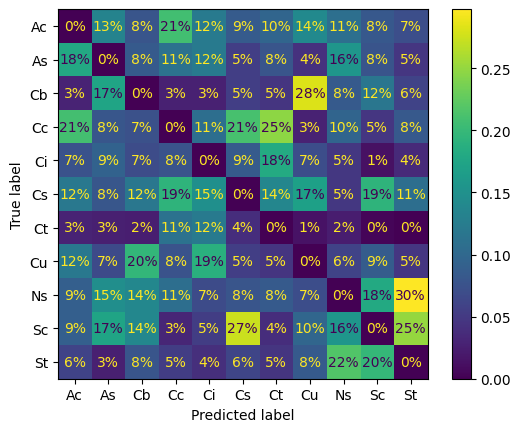

In [170]:
zeroed_conf_mx_row = ConfusionMatrixDisplay.from_predictions(y_train_labels, y_train_pred_labels,
                                                             sample_weight=sample_weight,
                                                             normalize="true", values_format=".0%")
zeroed_conf_mx_norm_col = ConfusionMatrixDisplay.from_predictions(y_train_labels, y_train_pred_labels,
                                                                  normalize="pred", values_format=".0%",
                                                                  labels=ordinal_encoder.classes_,
                                                                  sample_weight=sample_weight)
plt.show()

In [184]:
def plot_image(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image)
    plt.axis("off")

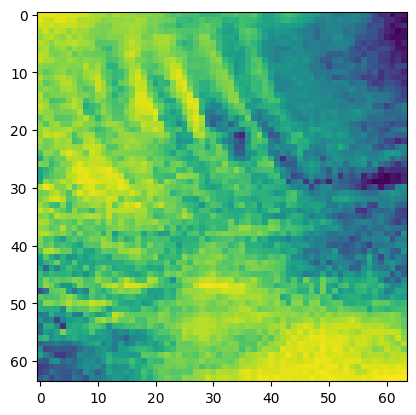

In [ ]:
cl_a, cl_b = 'Ct', 'Cc'
idx_a = ordinal_encoder.transform([cl_a])[0]
idx_b = ordinal_encoder.transform([cl_b])[0]
X_aa = X_train[(y_train == idx_a) & (y_train_pred == idx_a)]
X_ab = X_train[(y_train == idx_a) & (y_train_pred == idx_b)]
X_ba = X_train[(y_train == idx_b) & (y_train_pred == idx_a)]
X_bb = X_train[(y_train == idx_b) & (y_train_pred == idx_b)]

plt.imshow(X_bb[0])
plt.show()


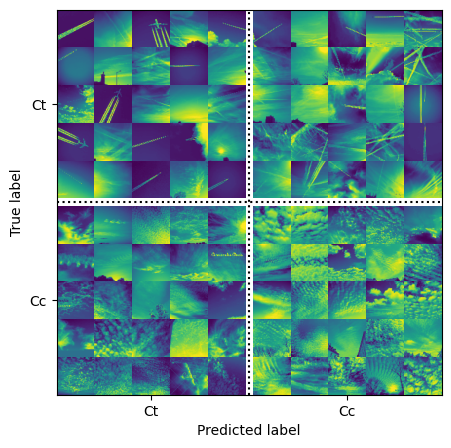

In [190]:
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(64, 64),
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")
# save_fig("error_analysis_digits_plot")
plt.show()

In [ ]:
y_test_pred = cross_val_predict(rf_clf, X_test_flat, y_test, cv=3)

In [ ]:
final_model = random_search.best_estimator_


In [ ]:
final_predictions = rf_clf.predict(X_test_flat)

In [197]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Accuracy
test_accuracy = accuracy_score(y_test, final_predictions)

# Precision (for binary classification, default 'binary' is usually used)
test_precision = precision_score(y_test, final_predictions, average='macro')

# Recall
test_recall = recall_score(y_test, final_predictions, average='micro')

# F1 Score
test_f1_score = f1_score(y_test, final_predictions, average='weighted')

print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1_score:.4f}")

Accuracy: 0.3006
Precision: 0.2823
Recall: 0.3006
F1 Score: 0.2821


In [ ]:


# mlp

In [109]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler



# pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
mlp_clf = MLPClassifier(max_iter=1000, random_state=42)


pipeline = Pipeline([("scaler", StandardScaler()), ("clf", mlp_clf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
            pipeline, X_train_flat, y_train,
            scoring="f1_macro",
            cv=cv,
            n_jobs=-1
        )


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: 

In [110]:
display_scores(scores)

Scores: [0.20804118 0.18606165 0.23401166 0.2481606  0.18107341]
Mean: 0.21146970173038207
Standard deviation: 0.02621305238144969


In [111]:
scores.best_validation_score_

AttributeError: 'numpy.ndarray' object has no attribute 'best_validation_score_'